##  Working Examples: Calibration of ODE Models

We'll try out some ODE calibration methods:

1. **Least squares (LS)**
2. **Likelihood-based inference** (Gaussian error and log-normal error)
3. **Smoothing-based calibration** (cubic splines & gradient matching)
4. **Approximate Bayesian Computation (ABC)**

Examples models
- One-compartment **PK elimination model**
- **Gompertz** tumor growth model
- **SIR** infectious disease model


Importing some dependencies 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Callable, Dict, Tuple, Optional

from scipy.integrate import solve_ivp # ODE solving function
from scipy.optimize import least_squares, minimize # for optimization
from scipy.interpolate import UnivariateSpline # for smoothing/splines 

Some utilities

In [2]:
def set_seed(seed: int = 123):
    np.random.seed(seed)

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def plot_obs_vs_fit(t, y, yhat, title, ylabel="y"):
    plt.figure(figsize=(7,4))
    plt.scatter(t, y, label="Observed", alpha=0.8)
    plt.plot(t, yhat, label="Fitted", linewidth=2)
    plt.xlabel("time")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


### I: Set up models and synthetic data 

In [3]:
# (1) PK drug elimination model 
# two errors: Gaussian/Normal error, or log-normal error term 

def pk_conc(t: np.ndarray, k: float, C0: float) -> np.ndarray:
    t = np.asarray(t)
    return C0 * np.exp(-k * t)

def simulate_pk_data(t, k_true=0.25, C0=10.0, sigma=0.5, error="gaussian", seed=123):
    set_seed(seed)
    C_true = pk_conc(t, k_true, C0)
    if error == "gaussian":
        y = C_true + np.random.normal(0, sigma, size=len(t))
    elif error == "lognormal":
        # log(y) = log(C_true) + N(0, sigma^2)
        y = C_true * np.exp(np.random.normal(0, sigma, size=len(t)))
    else:
        raise ValueError("error must be 'gaussian' or 'lognormal'")
    return C_true, y


In [4]:
# (2) Gompertz model 
# assuming Gaussian random observation error 

def gompertz_rhs(t, y, r, K):
    V = y[0]
    dV = r * V * np.log(K / max(V, 1e-12))
    return [dV]

def solve_gompertz(t_eval, r, K, V0):
    sol = solve_ivp(
        fun=lambda t, y: gompertz_rhs(t, y, r, K),
        t_span=(float(np.min(t_eval)), float(np.max(t_eval))),
        y0=[V0],
        t_eval=np.asarray(t_eval),
        method="RK45",
        rtol=1e-7,
        atol=1e-9
    )
    if not sol.success:
        raise RuntimeError("Gompertz ODE solve failed.")
    return sol.y[0]

def simulate_gompertz_data(t, r_true=0.35, K_true=1200.0, V0=50.0, sigma=30.0, seed=123):
    set_seed(seed)
    V_true = solve_gompertz(t, r_true, K_true, V0)
    y = V_true + np.random.normal(0, sigma, size=len(t))
    return V_true, y


In [5]:
# (3) SIR model 
def sir_rhs(t, y, beta, gamma):
    S, I, R = y
    dS = -beta * S * I
    dI = beta * S * I - gamma * I
    dR = gamma * I
    return [dS, dI, dR]

def solve_sir(t_eval, beta, gamma, S0=0.99, I0=0.01, R0=0.0):
    sol = solve_ivp(
        fun=lambda t, y: sir_rhs(t, y, beta, gamma),
        t_span=(float(np.min(t_eval)), float(np.max(t_eval))),
        y0=[S0, I0, R0],
        t_eval=np.asarray(t_eval),
        method="RK45",
        rtol=1e-7,
        atol=1e-9
    )
    if not sol.success:
        raise RuntimeError("SIR ODE solve failed.")
    S, I, R = sol.y
    return S, I, R

def simulate_sir_data(t, beta_true=0.9, gamma_true=0.4, S0=0.99, I0=0.01, R0=0.0,
                      sigma=0.01, seed=123):
    set_seed(seed)
    _, I_true, _ = solve_sir(t, beta_true, gamma_true, S0, I0, R0)
    I_obs = I_true + np.random.normal(0, sigma, size=len(t))
    # clip to keep prevalence in [0,1]
    I_obs = np.clip(I_obs, 0.0, 1.0)
    return I_true, I_obs

#### Create synthetic data and visualize

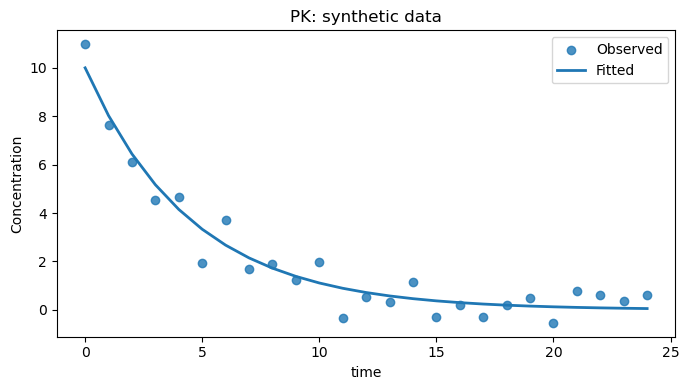

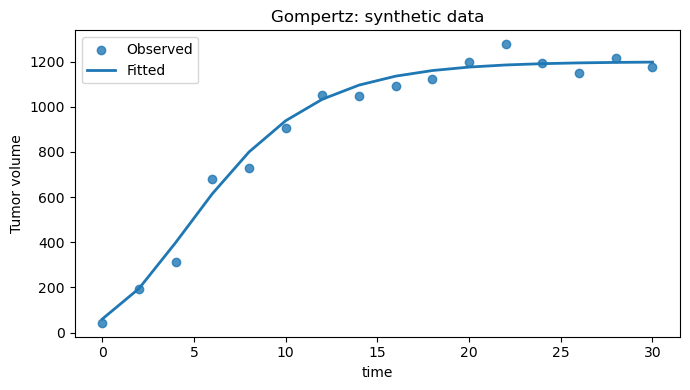

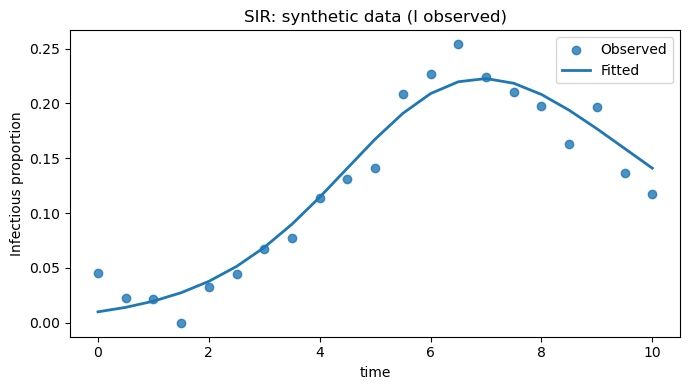

In [8]:
# PK data
t_pk = np.linspace(0, 24, 25)
C_true, C_obs = simulate_pk_data(t_pk, k_true=0.22, C0=10.0, sigma=0.6, error="gaussian", seed=1)

# Gompertz data
t_g = np.linspace(0, 30, 16)
V_true, V_obs = simulate_gompertz_data(t_g, r_true=0.25, K_true=1200.0, V0=60.0, sigma=40.0, seed=2)

# SIR data (observe I only)
t_sir = np.linspace(0, 10, 21)
#t_sir = np.linspace(0, 5, 21)
I_true, I_obs = simulate_sir_data(t_sir, beta_true=1.2, gamma_true=0.5, sigma=0.02, seed=3)

# quick plots
plot_obs_vs_fit(t_pk, C_obs, C_true, "PK: synthetic data", ylabel="Concentration")
plot_obs_vs_fit(t_g, V_obs, V_true, "Gompertz: synthetic data", ylabel="Tumor volume")
plot_obs_vs_fit(t_sir, I_obs, I_true, "SIR: synthetic data (I observed)", ylabel="Infectious proportion")


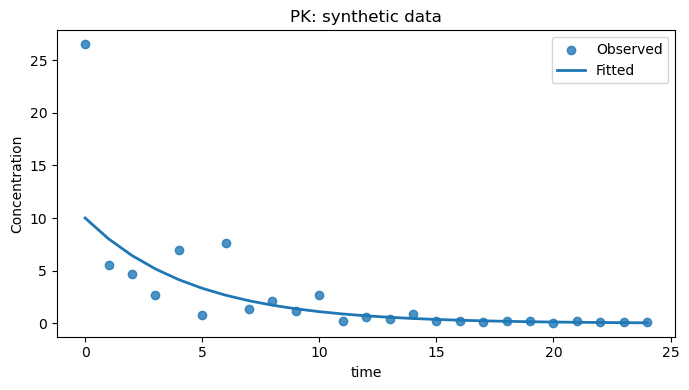

In [6]:
# PK data, log-normal error?
t_pk = np.linspace(0, 24, 25)
C_true2, C_obs2 = simulate_pk_data(t_pk, k_true=0.22, C0=10.0, sigma=0.6, error="lognormal", seed=1)

plot_obs_vs_fit(t_pk, C_obs2, C_true2, "PK: synthetic data", ylabel="Concentration")

### II: Calibration by least squares

In [8]:
?least_squares

PK LS estimate k_hat = 0.23152212619637
RMSE = 0.6368417905719547


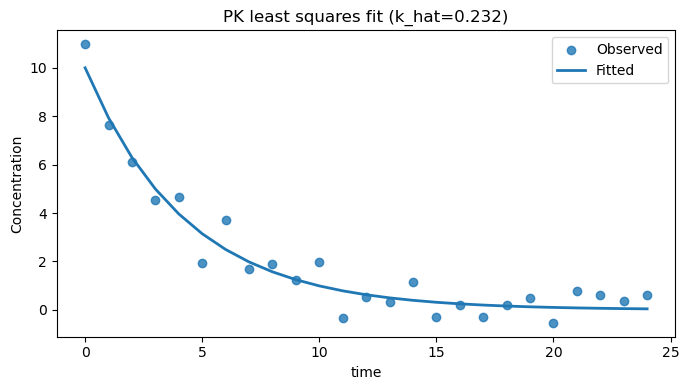

In [10]:
## PK model
def fit_pk_least_squares(t, y, C0_fixed: float, k_init=0.1):
    # residuals for least squares
    def resid(theta):
        k = theta[0]
        yhat = pk_conc(t, k, C0_fixed) # solution of ODE 
        return y - yhat

    res = least_squares(resid, # function for residual 
                        x0=np.array([k_init]),  # initial guess on parameter k (decay rate)
                        bounds=(0.0, np.inf)) # specify bounds on parameter 
    k_hat = float(res.x[0])
    return k_hat, res

k_hat_ls, res_ls = fit_pk_least_squares(t_pk, C_obs, C0_fixed=10.0, k_init=0.15) # calibration

# predict using the calibrated model
C_hat_ls = pk_conc(t_pk, 
                   k_hat_ls, # LS solution 
                   10.0) 

print("PK LS estimate k_hat =", k_hat_ls)
print("RMSE =", rmse(C_obs, C_hat_ls))
plot_obs_vs_fit(t_pk, C_obs, C_hat_ls, f"PK least squares fit (k_hat={k_hat_ls:.3f})", ylabel="Concentration")


Gompertz LS estimates: r_hat = 0.23815734064059035  K_hat = 1203.5401244983839
RMSE = 45.074603334726596


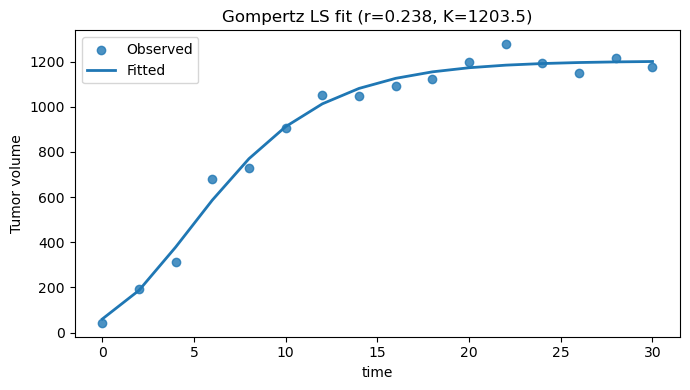

In [11]:
## Gompertz model
def fit_gompertz_least_squares(t, y, V0: float, init=(0.2, 1000.0)):
    def resid(theta):
        # here, two parameters 
        r, K = theta 
        # enforce positivity
        if r <= 0 or K <= 0:
            return 1e6 * np.ones_like(y)
        yhat = solve_gompertz(t, r, K, V0)
        return y - yhat

    
    res = least_squares(resid, x0=np.array(init), 
                        bounds=([1e-6, 1e-3], [5.0, 1e6])) 
    # bounds: r>0, K>0 (numerically set infinitesimal/finite bounds)
    
    r_hat, K_hat = map(float, res.x)
    return (r_hat, K_hat), res

(r_hat_ls, K_hat_ls), res_g_ls = fit_gompertz_least_squares(t_g, V_obs, V0=60.0, init=(0.2, 1500.0))
V_hat_ls = solve_gompertz(t_g, r_hat_ls, K_hat_ls, 60.0)

print("Gompertz LS estimates: r_hat =", r_hat_ls, " K_hat =", K_hat_ls)
print("RMSE =", rmse(V_obs, V_hat_ls))
plot_obs_vs_fit(t_g, V_obs, V_hat_ls, f"Gompertz LS fit (r={r_hat_ls:.3f}, K={K_hat_ls:.1f})", ylabel="Tumor volume")


SIR LS estimates: beta_hat = 1.2272360175491652  gamma_hat = 0.5139819322469061
RMSE = 0.01832988964226558


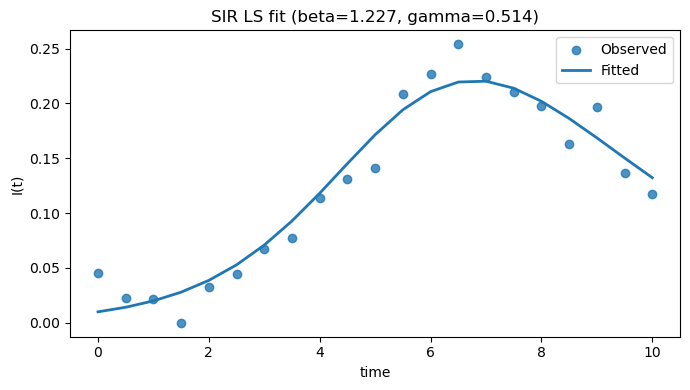

In [12]:
## SIR model

def fit_sir_least_squares(t, I_obs, S0=0.99, I0=0.01, R0=0.0, init=(1.0, 0.3)):
    def resid(theta):
        beta, gamma = theta
        # again, two parameters here 
        if beta <= 0 or gamma <= 0:
            return 1e6 * np.ones_like(I_obs)
        _, I_hat, _ = solve_sir(t, beta, gamma, S0, I0, R0)
        return I_obs - I_hat

    res = least_squares(resid, 
                        x0=np.array(init), 
                        bounds=([1e-6, 1e-6], [10.0, 10.0])) # and, similarly, beta, gamma > 0 
    beta_hat, gamma_hat = map(float, res.x)
    return (beta_hat, gamma_hat), res

(beta_hat_ls, gamma_hat_ls), res_sir_ls = fit_sir_least_squares(t_sir, I_obs, init=(1.0, 0.4))
_, I_hat_ls, _ = solve_sir(t_sir, beta_hat_ls, gamma_hat_ls)

print("SIR LS estimates: beta_hat =", beta_hat_ls, " gamma_hat =", gamma_hat_ls)
print("RMSE =", rmse(I_obs, I_hat_ls))
plot_obs_vs_fit(t_sir, I_obs, I_hat_ls, f"SIR LS fit (beta={beta_hat_ls:.3f}, gamma={gamma_hat_ls:.3f})", ylabel="I(t)")


### Calibration via likelihood-based inference 

Here we consider the PK model with Gaussian and log-Gaussian error models. 

The likelihood is thus constructed by applying the Normal or log-Normal densities on observation error terms. 

PK Gaussian MLE: k_hat = 0.23152217716131804  sigma_hat = 0.6368417909293884


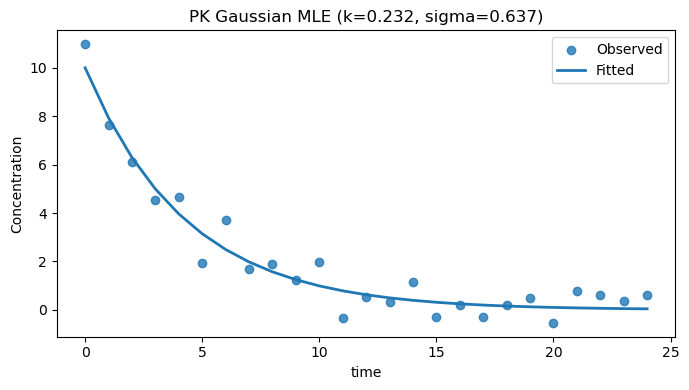

In [13]:
## PK model, Gaussian error model 

def nll_pk_gaussian(theta, t, y, C0):
    # theta = [k, log_sigma]
    k, log_sigma = theta
    if k <= 0:
        return np.inf
    sigma = np.exp(log_sigma)
    yhat = pk_conc(t, k, C0)
    resid = y - yhat
    return 0.5 * np.sum(np.log(2*np.pi*sigma**2) + (resid**2)/(sigma**2))

def fit_pk_mle_gaussian(t, y, C0, init=(0.15, np.log(0.5))):
    res = minimize(
        fun=lambda th: nll_pk_gaussian(th, t, y, C0),
        x0=np.array(init),
        method="L-BFGS-B",
        bounds=[(1e-8, None), (np.log(1e-6), np.log(1e3))]
    )
    k_hat = float(res.x[0])
    sigma_hat = float(np.exp(res.x[1]))
    return (k_hat, sigma_hat), res

(k_hat_mle, sigma_hat_mle), res_pk_mle = fit_pk_mle_gaussian(t_pk, C_obs, C0=10.0)
C_hat_mle = pk_conc(t_pk, k_hat_mle, 10.0)

print("PK Gaussian MLE: k_hat =", k_hat_mle, " sigma_hat =", sigma_hat_mle)
plot_obs_vs_fit(t_pk, C_obs, C_hat_mle, f"PK Gaussian MLE (k={k_hat_mle:.3f}, sigma={sigma_hat_mle:.3f})", ylabel="Concentration")


PK log-normal MLE: k_hat = 0.21855220387844165  sigma_hat = 0.2195526806361591


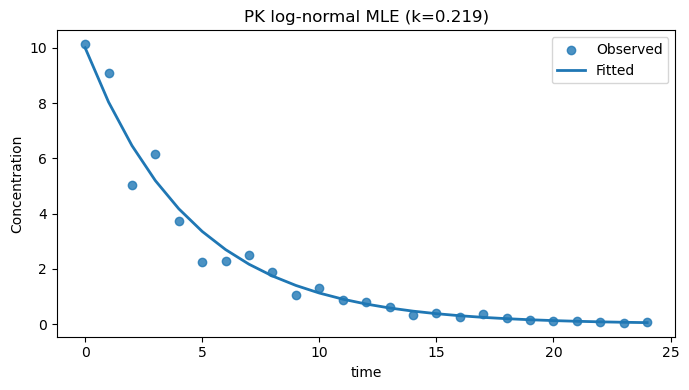

In [14]:
## PK model, log-normal error term 

def nll_pk_lognormal(theta, t, y, C0):
    # log(y) = log(C(t;k)) + N(0, sigma^2), with y>0
    k, log_sigma = theta
    if k <= 0:
        return np.inf
    if np.any(y <= 0):
        return np.inf
    sigma = np.exp(log_sigma)
    mu = np.log(pk_conc(t, k, C0) + 1e-12)
    z = np.log(y) - mu
    return 0.5 * np.sum(np.log(2*np.pi*sigma**2) + (z**2)/(sigma**2))

def fit_pk_mle_lognormal(t, y, C0, init=(0.15, np.log(0.2))):
    res = minimize(
        fun=lambda th: nll_pk_lognormal(th, t, y, C0),
        x0=np.array(init), # need: k, sigma
        method="L-BFGS-B",
        bounds=[(1e-8, None), (np.log(1e-6), np.log(1e3))]
    )
    k_hat = float(res.x[0])
    sigma_hat = float(np.exp(res.x[1]))
    return (k_hat, sigma_hat), res

# regenerate PK data with lognormal noise for demo
C_true_ln, C_obs_ln = simulate_pk_data(t_pk, k_true=0.22, C0=10.0, sigma=0.25, error="lognormal", seed=4)

# predict PK data with fitted parameter values 
(k_hat_ln, sigma_hat_ln), res_pk_ln = fit_pk_mle_lognormal(t_pk, C_obs_ln, C0=10.0)
C_hat_ln = pk_conc(t_pk, k_hat_ln, 10.0)

print("PK log-normal MLE: k_hat =", k_hat_ln, " sigma_hat =", sigma_hat_ln)
plot_obs_vs_fit(t_pk, C_obs_ln, C_hat_ln, f"PK log-normal MLE (k={k_hat_ln:.3f})", ylabel="Concentration")


In [9]:
?minimize

### IV: Calibration via smoothing and gradient-matching 

We show this for the Gompertz growth model, using cubic splines for smoothing. 

In [15]:
## Define a function that does (1) cubic spline fitting and (2) least squares style gradient matching

def fit_gompertz_spline_gradient_matching(t, y, spline_s: Optional[float]=None, init=(0.2, 1000.0)):
    """
    1) Fit cubic smoothing spline Vhat(t)
    2) Compute derivative Vhat'(t)
    3) Fit (r,K) by matching Vhat'(t_i) ≈ r Vhat(t_i) log(K/Vhat(t_i))
    """
    t = np.asarray(t)
    y = np.asarray(y)

    # cubic spline smoothing
    # s controls smoothness; if None, scipy chooses something based on len(t)
    spline = UnivariateSpline(t, y, k=3, s=spline_s)
    Vhat = spline(t)
    dVhat = spline.derivative(1)(t)

    # objective for gradient matching
    def obj(theta):
        r, K = theta
        if r <= 0 or K <= 0:
            return 1e12
        V = np.maximum(Vhat, 1e-12)
        pred = r * V * np.log(K / V)
        return np.sum((dVhat - pred) ** 2)

    res = minimize(
        fun=obj,
        x0=np.array(init),
        method="L-BFGS-B",
        bounds=[(1e-8, 10.0), (1e-3, 1e7)]
    )
    r_hat, K_hat = map(float, res.x)
    return (r_hat, K_hat), spline, res


Gompertz gradient matching estimates: r_hat = 0.26151454992232953  K_hat = 1169.2526185219072


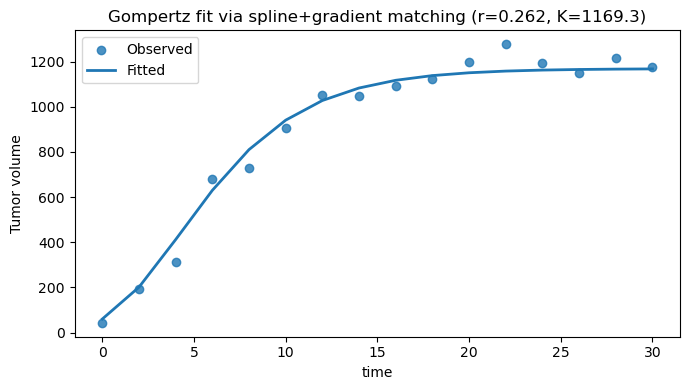

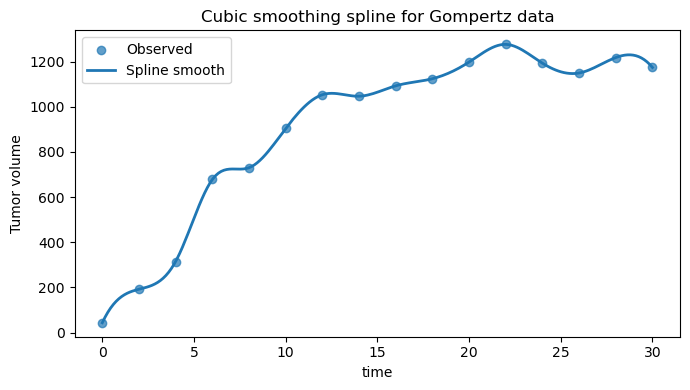

In [16]:
## fit the model and plot results 

(r_hat_gm, K_hat_gm), spline, res_gm = fit_gompertz_spline_gradient_matching(
    t_g, V_obs, spline_s=None, init=(0.2, 1500.0)
)

# Compare fitted ODE trajectory using (r_hat_gm, K_hat_gm)
V_hat_gm = solve_gompertz(t_g, r_hat_gm, K_hat_gm, V0=60.0)

print("Gompertz gradient matching estimates: r_hat =", r_hat_gm, " K_hat =", K_hat_gm)
plot_obs_vs_fit(t_g, V_obs, V_hat_gm, f"Gompertz fit via spline+gradient matching (r={r_hat_gm:.3f}, K={K_hat_gm:.1f})", ylabel="Tumor volume")

# show spline and derivative fit qualitatively
plt.figure(figsize=(7,4))
tt = np.linspace(t_g.min(), t_g.max(), 200)
plt.scatter(t_g, V_obs, label="Observed", alpha=0.7)
plt.plot(tt, spline(tt), label="Spline smooth", linewidth=2)
plt.xlabel("time")
plt.ylabel("Tumor volume")
plt.title("Cubic smoothing spline for Gompertz data")
plt.legend()
plt.tight_layout()
plt.show()


### V: Calibration via approximate Bayesian computation (ABC)

We implement a simple reject/accept ABC for three models: PK elimination, Gompertz growth, and SIR

Start by defining the ABC standard routine 

In [17]:
def abc_rejection(
    sample_prior: Callable[[int], np.ndarray],
    simulate: Callable[[np.ndarray], np.ndarray],
    distance: Callable[[np.ndarray, np.ndarray], float],
    y_obs: np.ndarray,
    n_prior: int = 20000,
    eps: float = 1.0,
    return_distances: bool = True
):
    """
    Parameters
    ----------
    sample_prior : callable
        Function that draws n samples from the prior.
        Input: n (int). Output: array of shape (n, d).

    simulate : callable
        Simulator mapping a parameter vector θ (shape (d,))
        to simulated data with the same structure as y_obs.

    distance : callable
        Distance function d(y_sim, y_obs) → non-negative scalar.

    y_obs : array-like
        Observed data used as the ABC target.

    n_prior : int, default=20000
        Number of prior samples.

    eps : float, default=1.0
        Acceptance tolerance ε. Accept θ if d(y_sim, y_obs) ≤ ε.

    return_distances : bool, default=True
        Whether to return distances for accepted samples.

    Returns
    -------
    accepted : ndarray
        Accepted parameter samples (approximate posterior).

    distances : ndarray
        Distances for accepted samples (if return_distances=True).

    thetas : ndarray
        All prior samples.
    """
    
    thetas = sample_prior(n_prior)
    accepted = []
    dists = []

    for th in thetas:
        y_sim = simulate(th) # simulate data given parameter value 
        d = distance(y_sim, y_obs) # compute distance between simulated data and observed data 
        if d <= eps: # distance < tolerance? then accept; otherwise reject 
            accepted.append(th)
            dists.append(d)

    accepted = np.asarray(accepted)
    dists = np.asarray(dists)
    if return_distances:
        return accepted, dists, thetas
    return accepted, thetas

def l2_distance(y_sim, y_obs): # example distance: L2 Euclidean distance 
    return float(np.linalg.norm(np.asarray(y_sim) - np.asarray(y_obs), ord=2))

def plot_abc_posterior(samples, names, title):
    if samples.size == 0:
        print("No accepted samples. Increase eps or n_prior.")
        return
    d = samples.shape[1]
    plt.figure(figsize=(6, 3.5))
    for j in range(d):
        plt.hist(samples[:, j], bins=30, alpha=0.6, density=True, label=names[j])
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


ABC-PK accepted: 575 out of 30000; eps = 3.2116945266737433


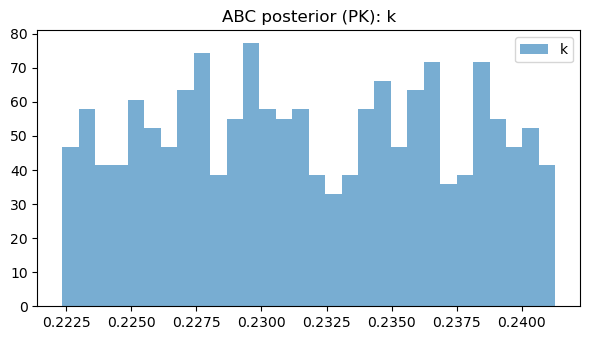

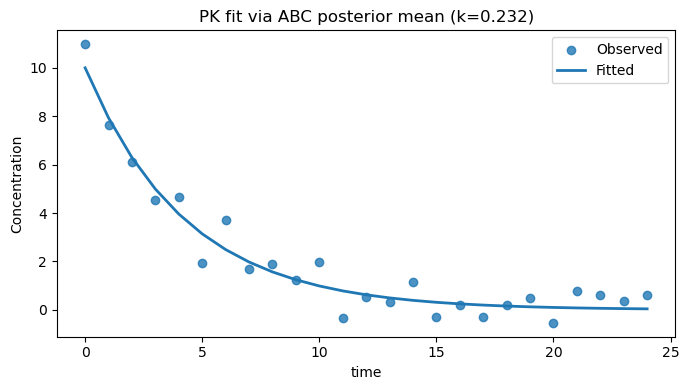

In [18]:
## PK model: observe with Gaussian noise, infer k only (initial C0 fixed)

y_obs_pk = C_obs.copy()
t = t_pk.copy()
C0 = 10.0

# Prior: k ~ Uniform(0, 1)
def prior_pk(n):
    k = np.random.uniform(0.0, 1.0, size=n)
    return k.reshape(-1, 1)

def simulate_pk(theta):
    k = float(theta[0])
    return pk_conc(t, k, C0)

# Choose eps by accepting a small quantile of distances:
set_seed(10)
thetas = prior_pk(5000)
d_try = np.array([l2_distance(simulate_pk(th), y_obs_pk) for th in thetas])
eps = np.quantile(d_try, 0.02)  # accept best ~2%

set_seed(11)
accepted_pk, dists_pk, _ = abc_rejection(
    sample_prior=prior_pk,
    simulate=simulate_pk,
    distance=l2_distance,
    y_obs=y_obs_pk,
    n_prior=30000,
    eps=float(eps),
)

print("ABC-PK accepted:", accepted_pk.shape[0], "out of 30000; eps =", float(eps))
plot_abc_posterior(accepted_pk, ["k"], "ABC posterior (PK): k")

# compare using posterior mean
k_abc_mean = float(np.mean(accepted_pk[:,0])) if accepted_pk.size else np.nan
yhat_abc = pk_conc(t, k_abc_mean, C0)
plot_obs_vs_fit(t, y_obs_pk, yhat_abc, f"PK fit via ABC posterior mean (k={k_abc_mean:.3f})", ylabel="Concentration")


In [23]:
## Another plotting function to show multiple parameters 

import math

def plot_abc_posterior_panels(
    samples,
    names,
    title,
    bins=30,
    log_scale=None
):
    """

    Parameters
    ----------
    samples : array-like, shape (n_samples, d)
        Posterior (accepted) samples.
    names : list of str, length d
        Parameter names for labeling.
    title : str
        Overall figure title.
    bins : int, default=30
        Number of histogram bins.
    log_scale : dict or None, default=None
        Dictionary indicating which parameters should be plotted on a log x-axis.
        Example: {"K": True}
    """
    samples = np.asarray(samples)
    if samples.size == 0:
        print("No accepted samples. Increase eps or n_prior.")
        return
    if samples.ndim == 1:
        samples = samples.reshape(-1, 1)

    n, d = samples.shape
    if len(names) != d:
        raise ValueError(f"len(names)={len(names)} but samples has d={d} columns.")

    if log_scale is None:
        log_scale = {}

    # Grid layout
    ncols = min(3, d)
    nrows = int(math.ceil(d / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.5 * ncols, 3.2 * nrows)
    )
    axes = np.atleast_1d(axes).ravel()

    for j in range(d):
        ax = axes[j]
        param_name = names[j]
        data = samples[:, j]

        # Handle log-scale parameters
        if log_scale.get(param_name, False):
            data = data[data > 0]  # safety for log scale
            ax.hist(data, bins=bins, density=True, alpha=0.8)
            ax.set_xscale("log")
            ax.set_xlabel(f"{param_name} (log scale)")
        else:
            ax.hist(data, bins=bins, density=True, alpha=0.8)
            ax.set_xlabel(param_name)

        ax.set_title(param_name)
        ax.set_ylabel("Density")

    # Hide unused axes
    for j in range(d, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()


In [26]:
## Gompertz model: observe growth data and infer (r, K); with V0 fixed
## (This takes a while to run!)

y_obs_g = V_obs.copy()
t = t_g.copy()
V0 = 60.0

# Priors: r ~ Uniform(0, 1), logK ~ Uniform(log(200), log(5000))  (log-uniform prior on K)
def prior_gompertz(n):
    r = np.random.uniform(0.0, 1.0, size=n)
    logK = np.random.uniform(np.log(200.0), np.log(5000.0), size=n)
    K = np.exp(logK)
    return np.column_stack([r, K])

def simulate_gompertz(theta):
    r, K = float(theta[0]), float(theta[1])
    return solve_gompertz(t, r, K, V0)

# Choose eps by pilot run (accept ~ 2% of proposals):
set_seed(20)
thetas = prior_gompertz(2000)
d_try = np.array([l2_distance(simulate_gompertz(th), y_obs_g) for th in thetas])
eps = np.quantile(d_try, 0.02)

set_seed(21)
accepted_g, dists_g, _ = abc_rejection(
    sample_prior=prior_gompertz,
    simulate=simulate_gompertz,
    distance=l2_distance,
    y_obs=y_obs_g,
    n_prior=15000,
    eps=float(eps),
)


ABC-Gompertz accepted: 351 out of 15000; eps = 622.9129842079665


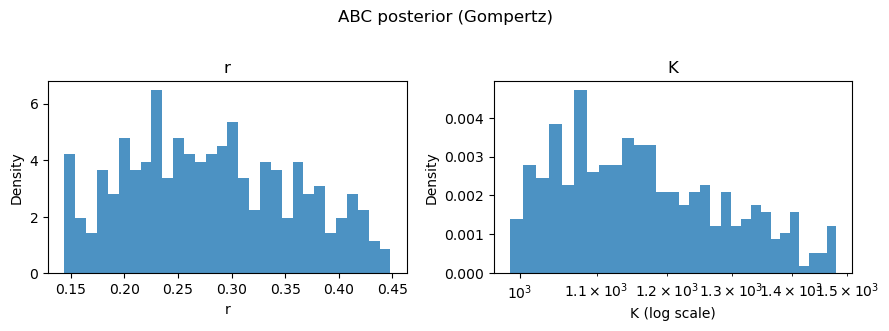

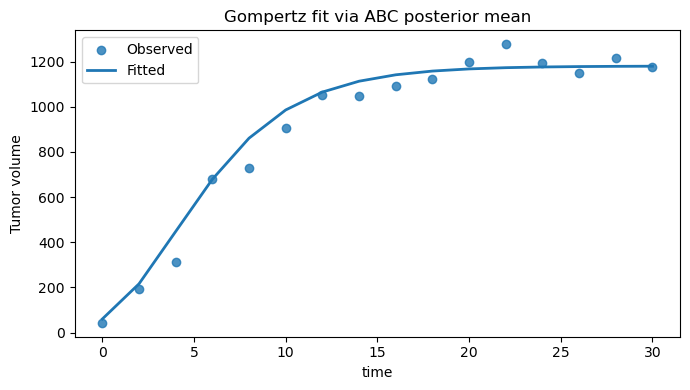

In [27]:
## Gompertz model: show results 

print("ABC-Gompertz accepted:", accepted_g.shape[0], "out of 15000; eps =", float(eps))

# plot posterior samples (those accepted)
plot_abc_posterior_panels(
    accepted_g,
    ["r", "K"],
    "ABC posterior (Gompertz)",
    log_scale={"K": True}
)

# posterior mean predicted vs observed 
if accepted_g.size:
    r_mean, K_mean = np.mean(accepted_g, axis=0)
    yhat = solve_gompertz(t, float(r_mean), float(K_mean), V0)
    plot_obs_vs_fit(t, y_obs_g, yhat, f"Gompertz fit via ABC posterior mean", ylabel="Tumor volume")


In [28]:
## SIR model: observe I(t) only and infer beta & gamma
## NOTE: this is even slower to run; takes a while... 

y_obs = I_obs.copy()
t = t_sir.copy()
S0, I0, R0 = 0.99, 0.01, 0.0

def prior_sir(n):
    beta = np.random.uniform(0.0, 3.0, size=n)
    gamma = np.random.uniform(0.0, 2.0, size=n)
    return np.column_stack([beta, gamma])

def simulate_sir_I(theta):
    beta, gamma = float(theta[0]), float(theta[1])
    _, I_hat, _ = solve_sir(t, beta, gamma, S0, I0, R0)
    return I_hat

# Pilot run to choose eps:
set_seed(30)
thetas = prior_sir(3000)
d_try = np.array([l2_distance(simulate_sir_I(th), y_obs) for th in thetas])
eps = np.quantile(d_try, 0.02) # again, want ~2% acceptance

set_seed(31)
accepted_sir, dists_sir, _ = abc_rejection(
    sample_prior=prior_sir,
    simulate=simulate_sir_I,
    distance=l2_distance,
    y_obs=y_obs,
    n_prior=20000,
    eps=float(eps),
)


ABC-SIR accepted: 417 out of 20000; eps = 0.2516234948132255


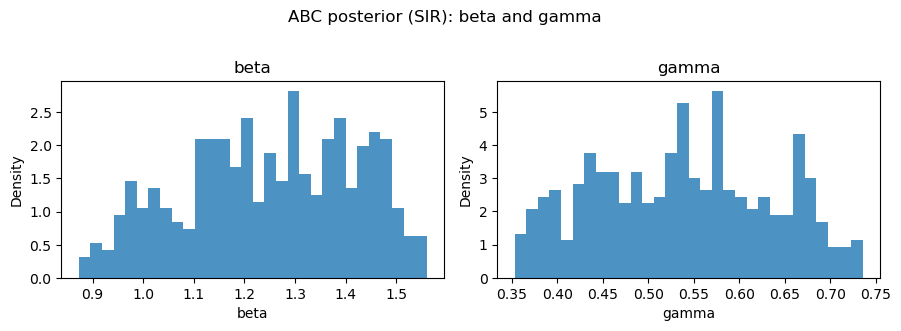

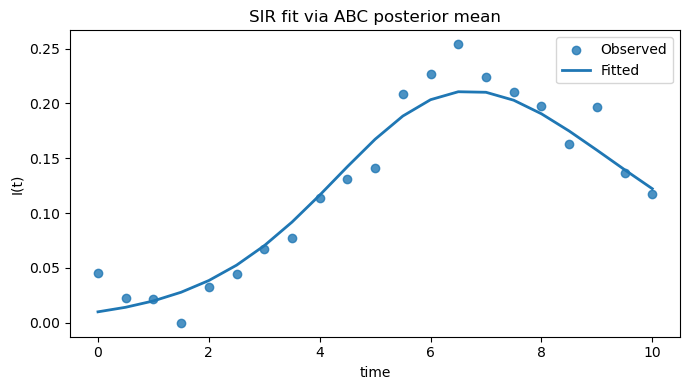

In [29]:
## SIR model: show ABC results 
print("ABC-SIR accepted:", accepted_sir.shape[0], "out of 20000; eps =", float(eps))

plot_abc_posterior_panels(
    accepted_sir,
    ["beta", "gamma"],
    title="ABC posterior (SIR): beta and gamma"
)

if accepted_sir.size:
    beta_mean, gamma_mean = np.mean(accepted_sir, axis=0)
    _, I_hat, _ = solve_sir(t, float(beta_mean), float(gamma_mean), S0, I0, R0)
    plot_obs_vs_fit(t, y_obs, I_hat, "SIR fit via ABC posterior mean", ylabel="I(t)")
